# Submission Comparison
Compares two test-set submission CSVs side by side.
- `test_amo.csv` — AMO (DINOv3 vit-base clean_trainval_43)
- `test_b16_full_3_stages.csv` — BEiT-16 full 3-stage pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

DIR = Path('.')
CSV_A = DIR / 'test_amo.csv'
# CSV_B = DIR / 'test_b16_full_3_stages_14317936.csv'
CSV_B = DIR / 'efficientnet_0025.csv'
LABEL_A = 'AMO (DINOv3)'
LABEL_B = 'Dino-16 3-stage'

df_a = pd.read_csv(CSV_A)
df_b = pd.read_csv(CSV_B)

print(f'Loaded {len(df_a)} rows from {CSV_A.name}')
print(f'Loaded {len(df_b)} rows from {CSV_B.name}')

Loaded 29980 rows from efficientnet_0025.csv
Loaded 29980 rows from test_b16_full_3_stages_14317936.csv


## 1. Coherence checks

In [20]:
issues = []

# Row count
if len(df_a) == len(df_b):
    print(f'✓  Row count matches: {len(df_a)}')
else:
    issues.append(f'✗  Row count mismatch: {len(df_a)} vs {len(df_b)}')
    print(issues[-1])

# Columns
if list(df_a.columns) == list(df_b.columns):
    print(f'✓  Columns match: {list(df_a.columns)}')
else:
    issues.append(f'✗  Column mismatch: {list(df_a.columns)} vs {list(df_b.columns)}')
    print(issues[-1])

# gender column: should all be 'x' for test
for name, df in [(LABEL_A, df_a), (LABEL_B, df_b)]:
    bad = (df['gender'] != 'x').sum()
    if bad == 0:
        print(f'✓  [{name}] gender column is all "x"')
    else:
        issues.append(f'✗  [{name}] {bad} rows with gender != "x"')
        print(issues[-1])

# Filename alignment (same order)
files_match = (df_a['filename'].values == df_b['filename'].values).all()
if files_match:
    print('✓  Filenames match and are in the same order')
else:
    n_diff = (df_a['filename'].values != df_b['filename'].values).sum()
    issues.append(f'✗  {n_diff} filenames differ or are out of order')
    print(issues[-1])
    # Check if same set at least
    set_a, set_b = set(df_a['filename']), set(df_b['filename'])
    only_a = set_a - set_b
    only_b = set_b - set_a
    if only_a or only_b:
        print(f'   Only in A: {len(only_a)} files | Only in B: {len(only_b)} files')
    else:
        print('   Same set of filenames, just different order — will sort-merge for comparison')
        df_a = df_a.sort_values('filename').reset_index(drop=True)
        df_b = df_b.sort_values('filename').reset_index(drop=True)

# NaN / out-of-range
for name, df in [(LABEL_A, df_a), (LABEL_B, df_b)]:
    n_nan = df['FaceOcclusion'].isna().sum()
    n_oob = ((df['FaceOcclusion'] < 0) | (df['FaceOcclusion'] > 1)).sum()
    if n_nan == 0 and n_oob == 0:
        print(f'✓  [{name}] FaceOcclusion: no NaN, all in [0, 1]')
    else:
        msg = f'✗  [{name}] {n_nan} NaN, {n_oob} out-of-range'
        issues.append(msg)
        print(msg)

print()
if not issues:
    print('All checks passed.')
else:
    print(f'{len(issues)} issue(s) found — see above.')

✓  Row count matches: 29980
✓  Columns match: ['filename', 'FaceOcclusion', 'gender']
✓  [AMO (DINOv3)] gender column is all "x"
✓  [Dino-16 3-stage] gender column is all "x"
✓  Filenames match and are in the same order
✓  [AMO (DINOv3)] FaceOcclusion: no NaN, all in [0, 1]
✓  [Dino-16 3-stage] FaceOcclusion: no NaN, all in [0, 1]

All checks passed.


## 2. Summary statistics

In [21]:
pred_a = df_a['FaceOcclusion'].values.astype(float)
pred_b = df_b['FaceOcclusion'].values.astype(float)
diff   = pred_a - pred_b

def describe(arr, label):
    return {
        'Model': label,
        'Mean':  f'{arr.mean():.4f}',
        'Std':   f'{arr.std():.4f}',
        'Var':   f'{arr.var():.6f}',
        'Min':   f'{arr.min():.4f}',
        'p5':    f'{np.percentile(arr, 5):.4f}',
        'p25':   f'{np.percentile(arr, 25):.4f}',
        'Median':f'{np.median(arr):.4f}',
        'p75':   f'{np.percentile(arr, 75):.4f}',
        'p95':   f'{np.percentile(arr, 95):.4f}',
        'Max':   f'{arr.max():.4f}',
        'Skew':  f'{stats.skew(arr):.3f}',
        'Kurt':  f'{stats.kurtosis(arr):.3f}',
    }

stats_df = pd.DataFrame([
    describe(pred_a, LABEL_A),
    describe(pred_b, LABEL_B),
    describe(diff,   f'Diff (A − B)'),
]).set_index('Model')

display(stats_df.T)

Model,AMO (DINOv3),Dino-16 3-stage,Diff (A − B)
Mean,0.1749,0.1688,0.0061
Std,0.0934,0.0986,0.0274
Var,0.008733,0.009719,0.000752
Min,0.0100,0.0133,-0.2596
p5,0.0394,0.0286,-0.0347
p25,0.0941,0.0826,-0.0093
Median,0.1709,0.1629,0.0056
p75,0.2453,0.2447,0.0202
p95,0.3370,0.3356,0.0488
Max,0.9723,0.5617,0.7050


## 3. Prediction distributions

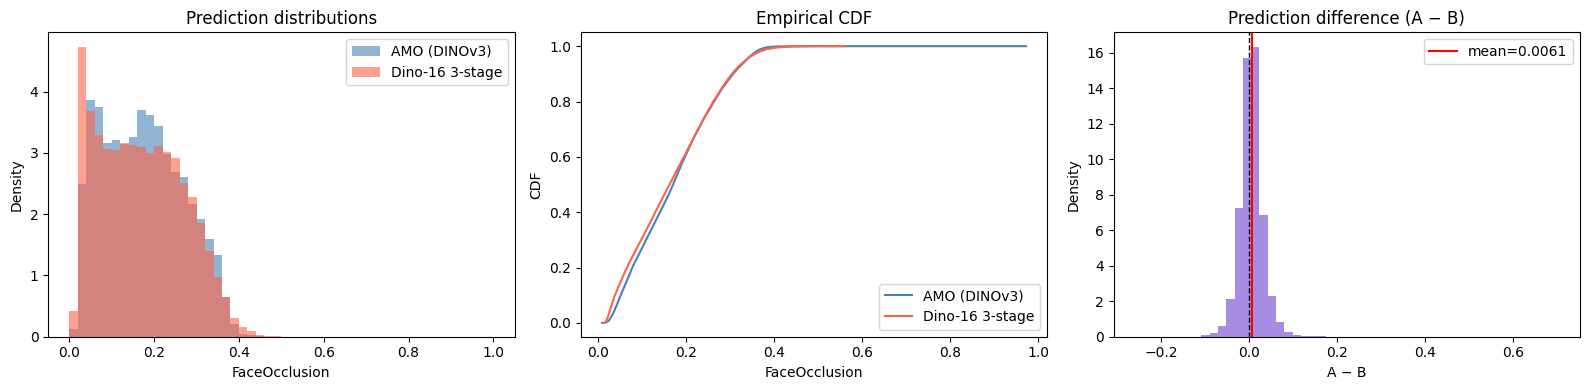

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

bins = np.linspace(0, 1, 51)

# Overlaid histogram
ax = axes[0]
ax.hist(pred_a, bins=bins, alpha=0.6, label=LABEL_A, color='steelblue', density=True)
ax.hist(pred_b, bins=bins, alpha=0.6, label=LABEL_B, color='tomato', density=True)
ax.set_xlabel('FaceOcclusion')
ax.set_ylabel('Density')
ax.set_title('Prediction distributions')
ax.legend()

# CDF
ax = axes[1]
for arr, label, color in [(pred_a, LABEL_A, 'steelblue'), (pred_b, LABEL_B, 'tomato')]:
    sorted_arr = np.sort(arr)
    cdf = np.arange(1, len(sorted_arr) + 1) / len(sorted_arr)
    ax.plot(sorted_arr, cdf, label=label, color=color)
ax.set_xlabel('FaceOcclusion')
ax.set_ylabel('CDF')
ax.set_title('Empirical CDF')
ax.legend()

# Difference histogram
ax = axes[2]
ax.hist(diff, bins=51, color='mediumpurple', alpha=0.8, density=True)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(diff.mean(), color='red', linewidth=1.5, linestyle='-', label=f'mean={diff.mean():.4f}')
ax.set_xlabel('A − B')
ax.set_ylabel('Density')
ax.set_title('Prediction difference (A − B)')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Scatter: predictions per sample (A vs B)

Pearson r        = 0.9606  (p=0.00e+00)
Spearman ρ       = 0.9629
MAE(A, B)        = 0.0201
RMSE(A, B)       = 0.0281
A predicts more  = 60.3% of samples
B predicts more  = 39.7% of samples


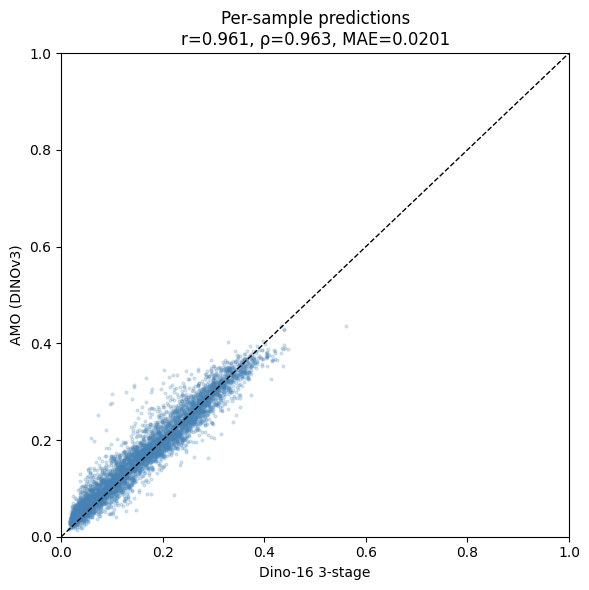

In [23]:
r, pval = stats.pearsonr(pred_a, pred_b)
rho, _ = stats.spearmanr(pred_a, pred_b)
mae    = np.abs(diff).mean()
rmse   = np.sqrt((diff ** 2).mean())

print(f'Pearson r        = {r:.4f}  (p={pval:.2e})')
print(f'Spearman ρ       = {rho:.4f}')
print(f'MAE(A, B)        = {mae:.4f}')
print(f'RMSE(A, B)       = {rmse:.4f}')
print(f'A predicts more  = {(pred_a > pred_b).mean()*100:.1f}% of samples')
print(f'B predicts more  = {(pred_b > pred_a).mean()*100:.1f}% of samples')

fig, ax = plt.subplots(figsize=(6, 6))
# subsample for speed if large
idx = np.random.default_rng(0).choice(len(pred_a), min(5000, len(pred_a)), replace=False)
ax.scatter(pred_b[idx], pred_a[idx], alpha=0.2, s=4, color='steelblue')
lims = [0, 1]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel(LABEL_B)
ax.set_ylabel(LABEL_A)
ax.set_title(f'Per-sample predictions\nr={r:.3f}, ρ={rho:.3f}, MAE={mae:.4f}')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Prediction range buckets — where do models disagree?

In [24]:
n_buckets = 10
bucket_edges = np.linspace(0, 1, n_buckets + 1)
bucket_labels = [f'[{bucket_edges[i]:.1f}, {bucket_edges[i+1]:.1f})' for i in range(n_buckets)]

# Use mean of A and B as bucket key
mean_pred = (pred_a + pred_b) / 2
bucket_idx = np.digitize(mean_pred, bucket_edges[1:-1])

rows = []
for i in range(n_buckets):
    mask = bucket_idx == i
    if mask.sum() == 0:
        continue
    d = diff[mask]
    rows.append({
        'Bucket (avg pred)': bucket_labels[i],
        'N samples': mask.sum(),
        'Mean(A)':  f'{pred_a[mask].mean():.4f}',
        'Mean(B)':  f'{pred_b[mask].mean():.4f}',
        'Mean(A−B)': f'{d.mean():.4f}',
        'Std(A−B)': f'{d.std():.4f}',
        'MAE(A,B)': f'{np.abs(d).mean():.4f}',
    })

display(pd.DataFrame(rows).set_index('Bucket (avg pred)'))

,N samples,Mean(A),Mean(B),Mean(A−B),Std(A−B),"MAE(A,B)"
Bucket (avg pred),,,,,,
"[0.0, 0.1)",8528,0.0648,0.0532,0.0116,0.0186,0.0169
"[0.1, 0.2)",9737,0.1548,0.1462,0.0086,0.0286,0.0217
"[0.2, 0.3)",8411,0.2466,0.2454,0.0012,0.0307,0.0220
"[0.3, 0.4)",3214,0.3332,0.3354,-0.0022,0.0263,0.0185
"[0.4, 0.5)",89,0.4015,0.4418,-0.0403,0.0306,0.0424
"[0.6, 0.7)",1,0.9723,0.2673,0.7050,0.0000,0.7050


## 6. Most divergent samples

In [25]:
comparison = pd.DataFrame({
    'filename': df_a['filename'],
    LABEL_A: pred_a,
    LABEL_B: pred_b,
    'abs_diff': np.abs(diff),
    'diff (A-B)': diff,
})

print('=== 20 samples where A predicts MUCH MORE than B ===')
display(comparison.nlargest(20, 'diff (A-B)')[['filename', LABEL_A, LABEL_B, 'diff (A-B)']].reset_index(drop=True))

print()
print('=== 20 samples where B predicts MUCH MORE than A ===')
display(comparison.nsmallest(20, 'diff (A-B)')[['filename', LABEL_A, LABEL_B, 'diff (A-B)']].reset_index(drop=True))

=== 20 samples where A predicts MUCH MORE than B ===


,filename,AMO (DINOv3),Dino-16 3-stage,diff (A-B)
0,database3/database3/m.016j74/24-FaceId-0_align...,0.972252,0.267251,0.705001
1,database3/database3/m.016hgp/32-FaceId-11_alig...,0.464377,0.132252,0.332124
2,database3/database3/m.01tny5b/35-FaceId-0_alig...,0.457566,0.153144,0.304423
3,database3/database3/m.026j34s/61-FaceId-0_alig...,0.353197,0.066291,0.286907
4,database3/database3/m.017hvr/67-FaceId-0_align...,0.342846,0.102519,0.240327
5,database3/database3/m.01vnlj1/13-FaceId-0_alig...,0.292946,0.069779,0.223167
6,database3/database3/m.025tggl/105-FaceId-0_ali...,0.412751,0.190421,0.222330
7,database3/database3/m.01k1gg1/48-FaceId-0_alig...,0.306699,0.086449,0.220250
8,database3/database3/m.01c59y/33-FaceId-0_align...,0.265947,0.048774,0.217173
9,database3/database3/m.028bql/56-FaceId-0_align...,0.351607,0.142530,0.209077



=== 20 samples where B predicts MUCH MORE than A ===


,filename,AMO (DINOv3),Dino-16 3-stage,diff (A-B)
0,database2/database2/train/1029.webp,0.206836,0.466413,-0.259576
1,database2/database2/test/14.webp,0.143930,0.383861,-0.239931
2,database3/database3/m.01qhf_2/8-FaceId-0_align...,0.223450,0.450465,-0.227015
3,database3/database3/m.027tm9b/127-FaceId-0_ali...,0.239539,0.399440,-0.159901
4,database3/database3/m.01wkmh5/50-FaceId-0_alig...,0.234441,0.384365,-0.149923
5,database3/database3/m.01vzsyj/75-FaceId-0_alig...,0.119786,0.269152,-0.149367
6,database3/database3/m.01p1qpl/73-FaceId-1_alig...,0.213124,0.352301,-0.139177
7,database2/database2/train/332.webp,0.085876,0.221065,-0.135189
8,database3/database3/m.01wn8gq/82-FaceId-0_alig...,0.179161,0.313392,-0.134231
9,database3/database3/m.0127tk/110-FaceId-0_alig...,0.182127,0.310193,-0.128066


## 7. Approximate competition metric on validation (if val CSVs available)

The test set has no ground truth, so the competition score cannot be computed directly.
If you have a `val.csv` for each model (with columns `FaceOcclusion`, `pred`, `gender`),
point the paths below to compute exact competition scores.

In [26]:
import sys
sys.path.insert(0, str(Path('..')))

try:
    from src.metrics import metric_fn
    metrics_available = True
except ImportError:
    metrics_available = False
    print('Could not import src.metrics — skipping val score computation')

# Set these to your val.csv paths if available
VAL_A = None   # e.g. Path('../submission/some_run_a/val.csv')
VAL_B = None   # e.g. Path('../submission/some_run_b/val.csv')

if metrics_available and VAL_A and VAL_B:
    import torch
    results = {}
    for name, path in [(LABEL_A, VAL_A), (LABEL_B, VAL_B)]:
        v = pd.read_csv(path)
        preds  = torch.tensor(v['pred'].values, dtype=torch.float32)
        labels = torch.tensor(v['FaceOcclusion'].values, dtype=torch.float32)
        gender = torch.tensor(v['gender'].values, dtype=torch.float32)
        score = metric_fn(preds, labels, gender).item()
        results[name] = score
        print(f'[{name}] val score = {score:.6f}')
    if len(results) == 2:
        delta = list(results.values())[0] - list(results.values())[1]
        print(f'Δ score (A − B) = {delta:+.6f}  ({'A is better' if delta < 0 else 'B is better'})')
else:
    print('Set VAL_A and VAL_B paths to compute competition scores on validation.')

Set VAL_A and VAL_B paths to compute competition scores on validation.


## 8. Score surrogate on test — weighted variance of predictions

Since test has no GT, here's a quick proxy: what fraction of predictions fall in the high-occlusion range (where the competition weight `w = 1/30 + GT` is largest).

In [27]:
thresholds = [0.1, 0.2, 0.3, 0.5, 0.7]
rows = []
for t in thresholds:
    rows.append({
        'Threshold': f'> {t}',
        f'{LABEL_A} (%)': f'{(pred_a > t).mean()*100:.2f}',
        f'{LABEL_B} (%)': f'{(pred_b > t).mean()*100:.2f}',
    })
print('Fraction of test samples with high occlusion predictions:')
display(pd.DataFrame(rows).set_index('Threshold'))

# Approximate competition weight-distribution (using predictions as proxy for GT)
print()
for arr, label in [(pred_a, LABEL_A), (pred_b, LABEL_B)]:
    w = 1/30 + arr          # weight if pred ≈ GT
    mean_w = w.mean()
    print(f'[{label}] mean competition weight (proxy) = {mean_w:.4f}')

Fraction of test samples with high occlusion predictions:


,AMO (DINOv3) (%),Dino-16 3-stage (%)
Threshold,,
> 0.1,73.22,69.57
> 0.2,39.35,38.69
> 0.3,11.57,11.02
> 0.5,0.00,0.01
> 0.7,0.00,0.00



[AMO (DINOv3)] mean competition weight (proxy) = 0.2082
[Dino-16 3-stage] mean competition weight (proxy) = 0.2021


## 9. DINO pipeline weights: iw, pi, gw — train / val / test

Replicates exactly the weight computation from `src/dino/utils.py` and `src/data/data_utils.py`.

- **iw** (importance weight): Laplacian ratio `(test_dist + α/N) / (train_dist + α/N)` per occlusion bin — upweights underrepresented bins relative to test distribution
- **pi** (label weight): `1/30 + FaceOcclusion` — the competition's own per-sample weight, grows linearly with occlusion
- **gw** (gender weight): per-(bin × gender) balancing so that female and male contribute equally across the occlusion range

Test set has no labels → iw = pi = gw = 1 for all samples.

In [ ]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path('..').resolve()))

from src.config import CSV_DIR, SCREENSHOT_PATH
from src.data.data_stats import get_test_distribution_from_screenshot, N_BINS
from src.data.data_utils import compute_gender_weights, N_BINS_GENDER, ALPHA_SMOOTH

# ── Config ───────────────────────────────────────────────────────────────────
SMOOTH_ALPHA = 0   # matches dino_cnn.yaml / dino_cnn_ft.yaml

# ── Load raw data + split (identical to pipeline: random_state=42, 80/20) ────
df_all = pd.read_csv(CSV_DIR / "train.csv").dropna().reset_index(drop=True)
df_train_raw, df_val_raw = train_test_split(df_all, test_size=0.2, random_state=42, shuffle=True)
df_train_raw = df_train_raw.reset_index(drop=True)
df_val_raw   = df_val_raw.reset_index(drop=True)

# ── iw: Laplacian importance weights ─────────────────────────────────────────
def compute_iw(df, alpha=SMOOTH_ALPHA):
    bins = np.linspace(0, 1, N_BINS + 1)
    n_ech = len(df)
    train_hist, _ = np.histogram(df["FaceOcclusion"], bins=bins)
    train_hist = train_hist / train_hist.sum()
    test_dist  = get_test_distribution_from_screenshot(SCREENSHOT_PATH, n_bins=N_BINS)
    ratio      = (test_dist + alpha / n_ech) / (1e-6 + train_hist + alpha / n_ech)
    y          = df["FaceOcclusion"].values
    bin_idx    = np.clip(np.digitize(y, bins) - 1, 0, N_BINS - 1)
    return ratio[bin_idx], ratio, test_dist, train_hist

iw_train, ratio_train, test_dist, hist_train = compute_iw(df_train_raw)
iw_val,   ratio_val,   _,         hist_val   = compute_iw(df_val_raw)

# ── pi: label weights (competition formula) ───────────────────────────────────
pi_train = 1/30 + df_train_raw["FaceOcclusion"].values
pi_val   = 1/30 + df_val_raw["FaceOcclusion"].values

# ── gw: gender-balancing weights ─────────────────────────────────────────────
def compute_gw(df):
    y  = torch.tensor(df["FaceOcclusion"].values, dtype=torch.float32)
    g  = torch.tensor(df["gender"].values,        dtype=torch.float32)
    W_F, W_M    = compute_gender_weights(y, g)
    bins_gender = torch.linspace(0, 1, N_BINS_GENDER + 1)
    bin_idx     = (torch.bucketize(y, bins_gender, right=False) - 1).clamp(0, N_BINS_GENDER - 1)
    gw          = torch.where(g == 0.0, W_F[bin_idx], W_M[bin_idx]).numpy()
    return gw, g.numpy(), W_F.numpy(), W_M.numpy()

gw_train, g_train, W_F_train, W_M_train = compute_gw(df_train_raw)
gw_val,   g_val,   W_F_val,   W_M_val   = compute_gw(df_val_raw)

y_train = df_train_raw["FaceOcclusion"].values
y_val   = df_val_raw["FaceOcclusion"].values

print(f"Train: {len(df_train_raw):,} samples  |  Val: {len(df_val_raw):,} samples")
print(f"iw  train  — mean={iw_train.mean():.3f}  std={iw_train.std():.3f}  "
      f"range=[{iw_train.min():.3f}, {iw_train.max():.3f}]")
print(f"iw  val    — mean={iw_val.mean():.3f}  std={iw_val.std():.3f}  "
      f"range=[{iw_val.min():.3f}, {iw_val.max():.3f}]")
print(f"pi  train  — mean={pi_train.mean():.3f}  std={pi_train.std():.3f}  "
      f"range=[{pi_train.min():.3f}, {pi_train.max():.3f}]")
print(f"gw  train  — mean={gw_train.mean():.3f}  std={gw_train.std():.3f}  "
      f"range=[{gw_train.min():.3f}, {gw_train.max():.3f}]")

In [ ]:
bin_centers = np.linspace(0, 1, N_BINS + 1)[:-1] + 0.5 / N_BINS
bins_iw     = np.linspace(0, 1, N_BINS + 1)
bins_gw     = np.linspace(0, 1, N_BINS_GENDER + 1)
gc_gw       = (bins_gw[:-1] + bins_gw[1:]) / 2

SUBSAMPLE = 8000   # scatter point cap

fig, axes = plt.subplots(4, 3, figsize=(17, 18))
fig.suptitle("DINO pipeline weights (iw, pi, gw) — train / val / test", fontsize=14, y=1.01)

for col, (split, y, iw, pi, gw, g, W_F, W_M, hist) in enumerate([
    ("train", y_train, iw_train, pi_train, gw_train, g_train, W_F_train, W_M_train, hist_train),
    ("val",   y_val,   iw_val,   pi_val,   gw_val,   g_val,   W_F_val,   W_M_val,   hist_val),
    ("test (no labels)", None, None, None, None, None, None, None, None),
]):
    # ── Row 0: test distribution vs split distribution ────────────────────────
    ax = axes[0, col]
    if y is not None:
        ax.bar(bin_centers, hist, width=1/N_BINS, alpha=0.5, color='steelblue', label=f'{split} dist')
        ax.plot(bin_centers, test_dist, color='tomato', linewidth=2, label='test dist (screenshot)')
        ax.set_title(f"[{split}] distribution vs test target")
    else:
        ax.text(0.5, 0.5, "No labels on test set\niw = 1 for all samples",
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title("[test] — no distribution available")
    ax.set_xlabel("FaceOcclusion"); ax.set_ylabel("density")
    ax.legend(fontsize=8)

    # ── Row 1: iw per sample ─────────────────────────────────────────────────
    ax = axes[1, col]
    if y is not None:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(y), min(SUBSAMPLE, len(y)), replace=False)
        ax.scatter(y[idx], iw[idx], alpha=0.15, s=4, color='steelblue')
        # binned mean line
        ax.step(bins_iw[:-1], ratio_train if col == 0 else ratio_val,
                where='post', color='tomato', linewidth=2, label='bin ratio (iw per bin)')
        ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f"[{split}] iw vs occlusion")
        ax.set_ylabel("iw")
        ax.legend(fontsize=8)
    else:
        ax.axhline(1, color='steelblue', linewidth=2)
        ax.set_ylim(0, 2); ax.set_title("[test] iw = 1 (constant)")
        ax.set_ylabel("iw")
    ax.set_xlabel("FaceOcclusion")

    # ── Row 2: pi per sample ──────────────────────────────────────────────────
    ax = axes[2, col]
    if y is not None:
        ax.scatter(y[idx], pi[idx], alpha=0.15, s=4, color='mediumpurple')
        x_line = np.linspace(0, 1, 100)
        ax.plot(x_line, 1/30 + x_line, color='tomato', linewidth=2, label='1/30 + y')
        ax.set_title(f"[{split}] pi (=1/30+y) vs occlusion")
        ax.legend(fontsize=8)
    else:
        ax.axhline(1, color='mediumpurple', linewidth=2)
        ax.set_ylim(0, 2); ax.set_title("[test] pi = 1 (constant)")
    ax.set_xlabel("FaceOcclusion"); ax.set_ylabel("pi")

    # ── Row 3: gw per sample, by gender ──────────────────────────────────────
    ax = axes[3, col]
    if y is not None and g is not None:
        f_mask = g[idx] == 0.0
        m_mask = g[idx] == 1.0
        ax.scatter(y[idx][f_mask], gw[idx][f_mask], alpha=0.15, s=4, color='orchid',  label='female')
        ax.scatter(y[idx][m_mask], gw[idx][m_mask], alpha=0.15, s=4, color='teal',    label='male')
        ax.step(gc_gw, W_F, where='mid', color='orchid', linewidth=2)
        ax.step(gc_gw, W_M, where='mid', color='teal',   linewidth=2)
        ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
        n_f = (g == 0.0).sum(); n_m = (g == 1.0).sum()
        ax.set_title(f"[{split}] gw vs occlusion  (F={n_f:,}, M={n_m:,})")
        ax.legend(fontsize=8)
    else:
        ax.axhline(1, color='gray', linewidth=2)
        ax.set_ylim(0, 2); ax.set_title("[test] gw = 1 (constant)")
    ax.set_xlabel("FaceOcclusion"); ax.set_ylabel("gw")

plt.tight_layout()
plt.show()

In [ ]:
# Weight distributions: iw, pi, gw histograms (train vs val)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Weight distributions — train vs val", fontsize=13)

for ax, (w_tr, w_va, title, color) in zip(axes, [
    (iw_train, iw_val, "iw  (importance weight)",   'steelblue'),
    (pi_train, pi_val, "pi  (1/30 + FaceOcclusion)", 'mediumpurple'),
    (gw_train, gw_val, "gw  (gender-balancing)",     'teal'),
]):
    ax.hist(w_tr, bins=40, alpha=0.6, density=True, color=color,   label=f'train  μ={w_tr.mean():.3f}')
    ax.hist(w_va, bins=40, alpha=0.6, density=True, color='tomato', label=f'val    μ={w_va.mean():.3f}')
    ax.set_title(title); ax.set_xlabel("weight"); ax.set_ylabel("density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary table
rows = []
for name, w_tr, w_va in [
    ("iw",  iw_train,  iw_val),
    ("pi",  pi_train,  pi_val),
    ("gw",  gw_train,  gw_val),
]:
    for split, w in [("train", w_tr), ("val", w_va)]:
        rows.append({
            "weight": name, "split": split,
            "mean": f"{w.mean():.4f}", "std":  f"{w.std():.4f}",
            "min":  f"{w.min():.4f}", "max":  f"{w.max():.4f}",
            "p25":  f"{np.percentile(w, 25):.4f}",
            "p50":  f"{np.percentile(w, 50):.4f}",
            "p75":  f"{np.percentile(w, 75):.4f}",
        })
display(pd.DataFrame(rows).set_index(["weight", "split"]))